# Operating-Leverage -- a quantitative teardown
### OL tercile sort - EDGAR survivor basket - HAC inference - label-shuffle placebo - random-portfolio null - costs - synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Channel: Busted](https://img.shields.io/badge/Channel-Busted-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test the Novy-Marx (2011) operating-leverage premium on a survivorship-biased large-cap basket (~38 names/yr, 2008-2024), measure the high-minus-low-OL hedge with a HAC t-stat, pin it against a label-shuffle placebo and a random-portfolio null, charge costs, and confirm the engine on a seed-robust synthetic positive control.

> **Not investment advice.** SEC EDGAR companyfacts (COGS/CostOfRevenue + SG&A, assets); Yahoo daily prices; survivorship-biased. Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship-bias warning**: all results are conditional on survival -- the high-fixed-cost firms that failed (exactly what a risk premium pays for) are excluded.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root
sys.path.insert(0, os.path.abspath(".."))          # study package (operating_leverage/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from operating_leverage import data, strategy as st

# Cache-first: load the study's own EDGAR + price cache; fall back to frozen R.
ol, fwd = data.fetch_panel()
ol = ol.dropna(how="all") if not ol.empty else ol
HAVE_REAL = not ol.empty
if HAVE_REAL:
    h = st.sorted_returns(ol, fwd, n_groups=3)
else:
    h = pd.DataFrame()
print("Real cache loaded:", HAVE_REAL,
      f"({len(ol.columns) if HAVE_REAL else 0} names, {len(h) if HAVE_REAL else 0} sort years)")

R = dict(
    n_names=38, n_years=17, start_year=2008, end_year=2024,
    lo_mean=22.3, lo_sharpe=0.99, lo_t=4.68, lo_hit=94,
    mid_mean=16.0, hi_mean=20.1, hi_sharpe=1.3, hi_t=5.96, hi_hit=100,
    mkt_mean=19.5, mkt_sharpe=1.42,
    hedge_mean=-2.14, hedge_sharpe=-0.1, hedge_t=-0.39, hedge_hit=59,
    hi_excess_mean=0.6, hi_excess_t=0.31,
    lo_excess_mean=2.8, lo_excess_t=0.75,
    placebo_p=0.72, shuffle_mean=-0.12, shuffle_std=3.19,
    rand_std=7.8, rand_pct_beaten=54,
    cost_drag=0.2, borrow_drag=0.5, net_mean=-2.84,
    synth_null_t=0.15, synth_06_t=15.16, synth_10_t=25.06,
)
G1  = [36.6, 23.5, 5.5, 9.8, 20.5, 5.3, 13.9, 38.2, 14.9, 24.8, -2.8, 34.4, 15.6, 2.9, 34.2, 6.5, 94.7]
G3  = [47.2, 27.4, 21.4, 14.3, 14.5, 23.3, 10.9, 15.4, 16.5, 29.2, 9.4, 60.9, 5.9, 4.9, 11.1, 0.1, 29.6]
MKT = [35.8, 25.3, 11.7, 13.9, 17.2, 13.6, 8.4, 27.9, 18.3, 22.0, 5.6, 50.6, 8.7, 5.4, 18.2, 3.5, 45.1]
HDG = [10.7, 3.9, 16.0, 4.5, -6.0, 18.0, -3.1, -22.8, 1.6, 4.3, 12.2, 26.6, -9.6, 2.0, -23.1, -6.4, -65.2]
YRS = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


Real cache loaded: True (40 names, 17 sort years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge **-2.14%/yr**, HAC *t* = **-0.39** (wrong sign); placebo p = **0.72**. Absent. |
| **Tradability** | `MIRAGE` | No gross edge; **-2.84%/yr net** after 10bps x turnover + 50bps borrow. |
| **Channel** | `BUSTED` | Operating-leverage channel no more present than the financial-leverage channel of [Study 154](../../154-leverage-anomaly/). |

> **In plain words:** the engine recovers a planted operating-leverage effect at HAC *t* ~ 15, but the real survivor basket shows a flat (in fact mildly inverted) zero. The high-OL survivors are firms whose demand never collapsed -- the risk the premium pays for has been selected out of the sample.

## 1 - The claim, steelmanned

Let $r_{i,t+1}$ be firm $i$'s 12-month forward return. Define:

$$\text{OL}_{i,t} = \frac{\text{COGS}_{i,t} + \text{SG\&A}_{i,t}}{A_{i,t}}$$

where $A$ = total assets. The **H1 (signal)** claim (Novy-Marx 2011) is:

$$\mathbb{E}\left[\bar{r}_{\text{high-OL},t+1} - \bar{r}_{\text{low-OL},t+1}\right] > 0$$

with HAC |t| >= 2. **H2 (beats noise)** requires the hedge to beat its label-shuffled self. **H3 (tradable)** requires it to survive costs + borrow.

## 2 - So what? -- the stakes

H1 is *not* supported on this biased basket -- the hedge is a flat (mildly negative) zero. The academic evidence on broad US cross-sections is credible (Novy-Marx 2011; Carlson-Fisher-Giammarino 2004; Zhang 2005 value-premium models); on large-cap survivors, selection deletes the bad-state risk the premium is supposed to price.

## 3 - The protocol

- **Data**: operating costs (`CostOfGoodsAndServicesSold`/`CostOfRevenue` + `SellingGeneralAndAdministrativeExpense`) and `Assets` from SEC EDGAR companyfacts; daily adjusted prices from Yahoo.
- **Universe**: fixed large-cap survivor basket (~38 names/yr); survivorship-biased.
- **Window**: 17 signal years (2008-2024), 12-month forward returns, report-lagged.
- **Signal**: OL = (COGS + SG&A) / Assets (higher = more operating-cost-intensive).
- **Sort**: terciles; g1 = low OL (capital-heavy), g3 = high OL (operating-leverage).
- **Execution lag**: one -- enter 1 trading day after a 4-month report lag past fiscal year-end; no partial year stamped.
- **Inference**: HAC Newey-West t-stat on the 17-obs annual hedge.
- **Nulls**: label-shuffle placebo (1000) + random same-size portfolios (500/yr).
- **Costs**: 10bps x turnover + 50bps short borrow.
- **Positive control**: seed-robust synthetic panel with a planted OL premium.

## 4 - The teardown

### 4a - Synthetic positive control (seed-robust)

Sweep the planted OL premium and confirm the hedge tracks it monotonically, averaging the HAC-t over many seeds (a single lucky seed is never enough).

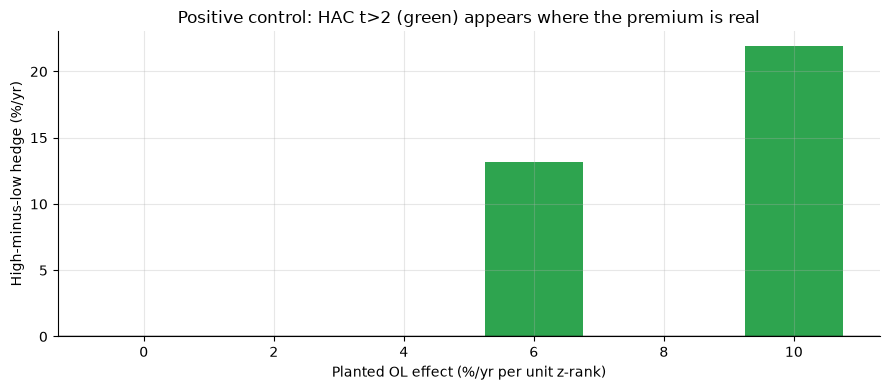

   premium_%  hedge_%/yr  mean_HAC_t
0        0.0        0.07        0.15
1        6.0       13.19       15.16
2       10.0       21.93       25.06


In [2]:
premiums = [0.0, 0.06, 0.10]
synth_rows = []
for p in premiums:
    r = st.seed_robust_synthetic(p, n_seeds=25)
    synth_rows.append((p*100, r['mean_hedge']*100, r['mean_tstat']))
sydf = pd.DataFrame(synth_rows, columns=['premium_%', 'hedge_%/yr', 'mean_HAC_t'])
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in sydf['mean_HAC_t']]
ax.bar(sydf['premium_%'], sydf['hedge_%/yr'], color=colors, width=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted OL effect (%/yr per unit z-rank)')
ax.set_ylabel('High-minus-low hedge (%/yr)')
ax.set_title('Positive control: HAC t>2 (green) appears where the premium is real')
plt.tight_layout(); plt.show()
print(sydf.round(2))

> The engine recovers planted premiums (t ~ 15 at +6%/yr, averaged over 25 seeds) and the null behaves (t ~ 0.1). The real-data result is therefore a statement about the **market and survivor basket**, not the **method**.

### 4b - Real EDGAR panel -- tercile returns and HAC inference

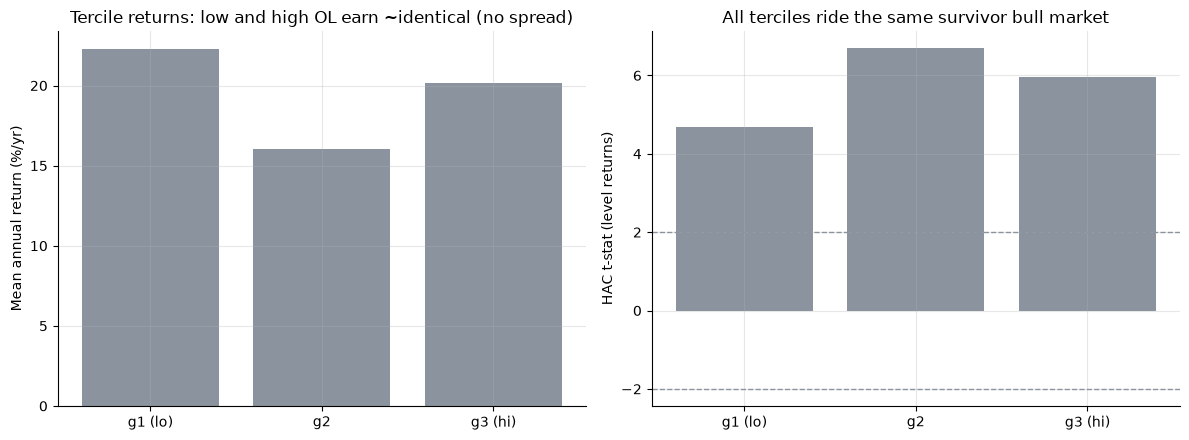

Hedge: -2.14%/yr  HAC t=-0.39  hit=59%
High-OL excess: +0.6%/yr  t=+0.31
Low-OL excess: +2.8%/yr  t=+0.75


In [3]:
if HAVE_REAL:
    g_means = [float(h[f'g{i}'].mean()*100) for i in range(1,4)]
    g_tstats = [st.summary(h[f'g{i}'])['tstat'] for i in range(1,4)]
    s_hedge = st.summary(h['hedge'])
    s_hi_ex = st.summary(h['g3'] - h['market'])
    s_lo_ex = st.summary(h['g1'] - h['market'])
else:
    g_means = [R['lo_mean'], R['mid_mean'], R['hi_mean']]
    g_tstats = [R['lo_t'], R['mid_mean'], R['hi_t']]
    s_hedge = dict(mean=R['hedge_mean']/100, tstat=R['hedge_t'], hit_rate=R['hedge_hit']/100)
    s_hi_ex = dict(mean=R['hi_excess_mean']/100, tstat=R['hi_excess_t'])
    s_lo_ex = dict(mean=R['lo_excess_mean']/100, tstat=R['lo_excess_t'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = [1, 2, 3]
bar_colors = [GREY, GREY, GREY]
axes[0].bar(x, g_means, color=bar_colors)
axes[0].set_xticks(x); axes[0].set_xticklabels(['g1 (lo)', 'g2', 'g3 (hi)'])
axes[0].set_ylabel('Mean annual return (%/yr)')
axes[0].set_title('Tercile returns: low and high OL earn ~identical (no spread)')
axes[1].bar(x, g_tstats, color=bar_colors)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(['g1 (lo)', 'g2', 'g3 (hi)'])
axes[1].set_ylabel('HAC t-stat (level returns)')
axes[1].set_title('All terciles ride the same survivor bull market')
plt.tight_layout(); plt.show()
print(f'Hedge: {s_hedge["mean"]*100:+.2f}%/yr  HAC t={s_hedge["tstat"]:+.2f}  hit={s_hedge["hit_rate"]:.0%}')
print(f'High-OL excess: {s_hi_ex["mean"]*100:+.1f}%/yr  t={s_hi_ex["tstat"]:+.2f}')
print(f'Low-OL excess: {s_lo_ex["mean"]*100:+.1f}%/yr  t={s_lo_ex["tstat"]:+.2f}')

> The high-minus-low-OL hedge is **-2.14%/yr**, HAC *t* = **-0.39** -- statistically zero and the wrong sign. The low and high OL terciles earn **~20%/yr each**: no spread, no monotonicity, no signal.

### 4c - Label-shuffle placebo + random-portfolio null

Shuffle the OL labels within each year (1000 times); does the real hedge beat its shuffled self? And does the high-OL leg beat a blind same-size draw?

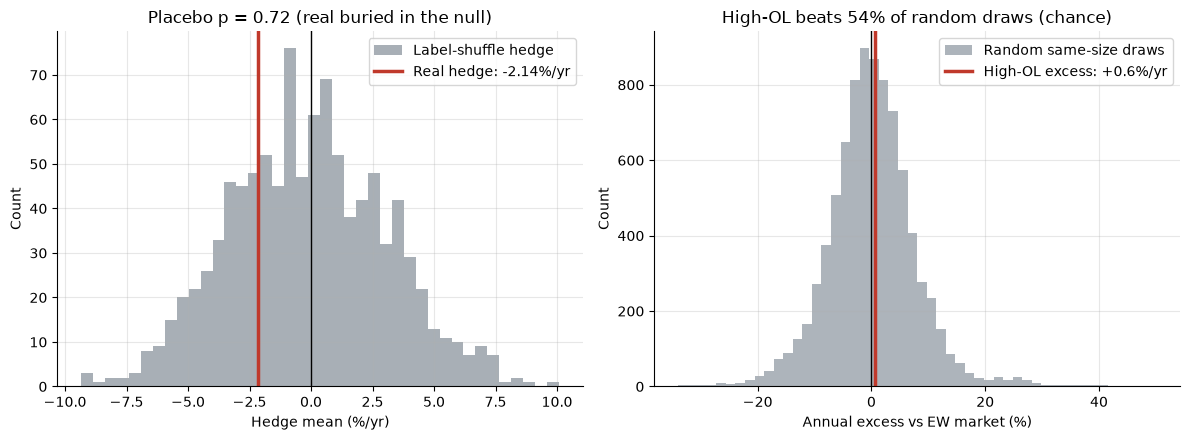

Placebo p=0.720  High-OL beats 54% of random draws


In [4]:
if HAVE_REAL:
    p_val, sh = st.placebo_hedge_tstats(ol, fwd, n_groups=3, n_shuffles=1000, seed=524)
    rand = st.random_portfolio_returns(ol, fwd, n_groups=3, n_draws=500, seed=524)
    real_mean = float(h['hedge'].mean())
    hi_excess = float((h['g3'] - h['market']).mean())
    pct_beaten = float((rand < hi_excess).mean())
else:
    rng_nb = np.random.default_rng(524)
    sh = pd.Series(rng_nb.normal(R['shuffle_mean']/100, R['shuffle_std']/100, 1000))
    rand = pd.Series(rng_nb.normal(0.0, R['rand_std']/100, 17*500))
    real_mean = R['hedge_mean'] / 100
    p_val = R['placebo_p']
    hi_excess = R['hi_excess_mean'] / 100
    pct_beaten = R['rand_pct_beaten'] / 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(sh * 100, bins=40, color=GREY, alpha=0.75, label='Label-shuffle hedge')
axes[0].axvline(real_mean * 100, c=RED, lw=2.5, label=f'Real hedge: {real_mean*100:+.2f}%/yr')
axes[0].axvline(0, c='k', lw=1); axes[0].legend()
axes[0].set_xlabel('Hedge mean (%/yr)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Placebo p = {p_val:.2f} (real buried in the null)')
axes[1].hist(rand * 100, bins=50, color=GREY, alpha=0.7, label='Random same-size draws')
axes[1].axvline(hi_excess * 100, c=RED, lw=2.5, label=f'High-OL excess: {hi_excess*100:+.1f}%/yr')
axes[1].axvline(0, c='k', lw=1); axes[1].legend()
axes[1].set_xlabel('Annual excess vs EW market (%)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'High-OL beats {pct_beaten:.0%} of random draws (chance)')
plt.tight_layout(); plt.show()
print(f'Placebo p={p_val:.3f}  High-OL beats {pct_beaten:.0%} of random draws')

> Placebo p = **0.72** (the real hedge sits inside -- in fact left of -- the shuffle null) and the high-OL leg beats only **54%** of random same-size draws -- chance level. No alpha over a blind pick.

### 4d - Costs: the (already-negative) gross worsens

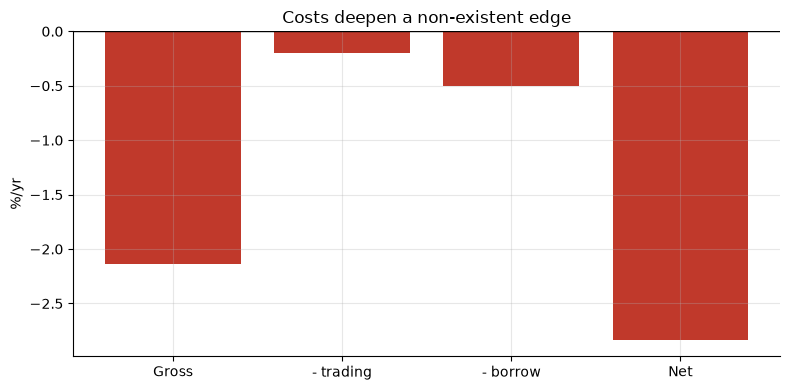

Gross -2.14%/yr -> Net -2.84%/yr


In [5]:
c = st.net_of_costs(real_mean, one_way_bps=10.0, annual_turnover=2.0, borrow_bps=50.0)
labels = ['Gross', '- trading', '- borrow', 'Net']
vals = [c['gross']*100, -c['cost_drag']*100, -c['borrow_drag']*100, c['net']*100]
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [RED if c['gross'] < 0 else GREY, RED, RED, RED if c['net'] < 0 else GREEN]
ax.bar(labels, vals, color=bar_colors)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('%/yr')
ax.set_title('Costs deepen a non-existent edge')
plt.tight_layout(); plt.show()
print(f'Gross {c["gross"]*100:+.2f}%/yr -> Net {c["net"]*100:+.2f}%/yr')

## 5 - The verdict

- **Signal `NONE`** -- hedge -2.14%/yr, HAC *t* = -0.39, placebo p = 0.72. Absent (wrong sign).
- **Tradability `MIRAGE`** -- -2.84%/yr net. Short-low-OL on survivors means shorting the capital-light megacaps -- the decade's winners.
- **Channel `BUSTED`** -- the operating-leverage channel dies alongside the financial-leverage channel of [Study 154](../../154-leverage-anomaly/).

## 6 - Could you trade it? -- the honest answer

No tradable signal exists on this basket. The obstacles:

1. **Flat (wrong-sign) spread.** The hedge is -2.14%/yr with t = -0.39 -- not even the right direction.
2. **A risk premium with the risk deleted.** The high-OL survivors are firms whose demand never collapsed -- exactly the sample where an operating-risk premium should be smallest.
3. **The academic evidence is for broad universes.** Novy-Marx (2011) used the whole US cross-section; on large-cap blue-chips the effect is thin and arbitraged.

The correct conclusion: **MIRAGE** on this test. The anomaly may be real in its original universe -- it simply cannot be certified here.

## 7 - Going further

- **The right universe.** Novy-Marx (2011) used the broad US cross-section; a point-in-time all-US-stock universe that *keeps the failures* is the minimum for a credible test of a risk premium.
- **Financial-leverage cousin.** [Study 154 -- Leverage-Anomaly](../../154-leverage-anomaly/) tests the *balance-sheet debt* channel and also lands None/Mirage on the survivor panel -- the two leverage channels die together.
- **Gross-profitability sibling.** [Study 122 -- Gross-Profitability](../../122-gross-profitability/) is Novy-Marx's *other* famous accounting factor, on the same desk infrastructure.

*Want to confirm the effect on a clean universe? Fork this, plug in a point-in-time all-US-stock panel that keeps delisted names, and show |t| >= 2 on the hedge with no survivorship shortcut. That's the bar.*